In [18]:
!pip install sentence-transformers torch "accelerate>=0.26.0"

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\piyus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
from sentence_transformers import SentenceTransformer

C:\Users\piyus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

In [4]:
text = "Embedding fine-tuning improves retrieval quality in RAG systems."

In [5]:
embedding = model.encode(text)

In [6]:
embedding

array([-4.31954227e-02, -6.37486018e-03,  9.89385098e-02, -5.49361408e-02,
       -1.11686118e-01,  7.33395619e-03,  1.22230193e-02, -3.27694870e-04,
       -1.20243840e-02, -5.08929193e-02, -2.30040122e-02,  6.07166030e-02,
        6.57067895e-02,  1.35162240e-02, -7.56544024e-02,  3.56635302e-02,
        9.49646682e-02,  1.69990391e-01, -8.21337625e-02, -5.11804894e-02,
       -6.61959723e-02,  3.54444794e-02,  6.89547807e-02, -5.40292822e-02,
       -3.87974158e-02, -7.20145460e-03, -8.89523476e-02, -2.07440443e-02,
        1.00668862e-01, -7.00350702e-02, -3.93861495e-02,  5.27501963e-02,
       -2.10089441e-02, -9.75626986e-03, -7.13353306e-02,  2.94415001e-02,
       -7.28627071e-02,  2.83689890e-02, -3.83581221e-02,  2.69834232e-02,
        6.83702470e-04,  8.22033808e-02, -1.09918080e-02,  1.40311215e-02,
        9.09943786e-03,  1.42066767e-02, -2.72481032e-02, -1.92144271e-02,
        1.83158778e-02, -1.99292097e-02, -4.79141250e-02, -6.14970038e-03,
        4.47927564e-02,  

In [8]:
import numpy as np

In [9]:
print("Embedding Shape:", embedding.shape)
print("First 10 Values:", np.round(embedding[:10], 6))

Embedding Shape: (384,)
First 10 Values: [-0.043195 -0.006375  0.098939 -0.054936 -0.111686  0.007334  0.012223
 -0.000328 -0.012024 -0.050893]


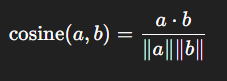

In [10]:
import numpy as np

def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

In [17]:
documents = [
    "Embedding fine-tuning improves retrieval in RAG.",
    "LoRA reduces GPU memory usage.",
    "My car needs fuel.",
    "Vector databases store embeddings.",
]

query = "How to improve retrieval in RAG?"

In [18]:
doc_embs = model.encode(documents, convert_to_numpy=True)
q_emb = model.encode(query, convert_to_numpy=True)

In [19]:
scores = [cosine_sim(q_emb, d_emb) for d_emb in doc_embs]

In [20]:
# Print all scores
for doc, score in zip(documents, scores):
    print(f"Score: {score:.4f}  |  {doc}")

Score: 0.7759  |  Embedding fine-tuning improves retrieval in RAG.
Score: 0.0830  |  LoRA reduces GPU memory usage.
Score: 0.0618  |  My car needs fuel.
Score: 0.0565  |  Vector databases store embeddings.


In [11]:
pairs = [
    ("Embedding improves semantic search",
     "Fine-tuned embeddings enhance retrieval"),

    ("Embedding improves semantic search",
     "I bought a new car yesterday"),
]

In [12]:
for s1, s2 in pairs:
    emb1, emb2 = model.encode([s1, s2], normalize_embeddings=True)
    score = cosine_sim(emb1, emb2)
    print(f"\nSentence 1: {s1}")
    print(f"Sentence 2: {s2}")
    print("Cosine Similarity:", round(score, 4))


Sentence 1: Embedding improves semantic search
Sentence 2: Fine-tuned embeddings enhance retrieval
Cosine Similarity: 0.754

Sentence 1: Embedding improves semantic search
Sentence 2: I bought a new car yesterday
Cosine Similarity: 0.0597


## Keyword Search vs Vector Search

In [22]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.metrics.pairwise import cosine_similarity

# documents = [
#     "Embedding fine-tuning improves retrieval in RAG.",
#     "LoRA reduces GPU memory usage.",
#     "My car needs fuel.",
#     "Vector databases store embeddings.",
# ]

# query = ["How to improve retrieval in RAG?"]

# # 1) TF-IDF vectorizer
# vectorizer = TfidfVectorizer()

# # 2) Fit on documents
# doc_vectors = vectorizer.fit_transform(documents)

# # 3) Transform query
# query_vector = vectorizer.transform(query)

# # 4) Cosine similarity
# scores = cosine_similarity(query_vector, doc_vectors)[0]

# print("=== Keyword Search (TF-IDF) ===")
# for doc, score in zip(documents, scores):
#     print(f"{score:.4f} | {doc}")

Doc tokens: [['embedding', 'fine', 'tuning', 'improves', 'retrieval', 'in', 'rag'], ['lora', 'reduces', 'gpu', 'memory', 'usage'], ['my', 'car', 'needs', 'fuel'], ['vector', 'databases', 'store', 'embeddings']]
Query tokens: ['how', 'to', 'improve', 'retrieval', 'in', 'rag']

Vocab: ['car', 'databases', 'embedding', 'embeddings', 'fine', 'fuel', 'gpu', 'how', 'improve', 'improves', 'in', 'lora', 'memory', 'my', 'needs', 'rag', 'reduces', 'retrieval', 'store', 'to', 'tuning', 'usage', 'vector']
IDF (sample): {'car': 1.916, 'databases': 1.916, 'embedding': 1.916, 'embeddings': 1.916, 'fine': 1.916, 'fuel': 1.916, 'gpu': 1.916, 'how': 2.609, 'improve': 2.609, 'improves': 1.916, 'in': 1.916, 'lora': 1.916, 'memory': 1.916, 'my': 1.916, 'needs': 1.916, 'rag': 1.916, 'reduces': 1.916, 'retrieval': 1.916, 'store': 1.916, 'to': 2.609, 'tuning': 1.916, 'usage': 1.916, 'vector': 1.916}

Query TF-IDF vector: [0.    0.    0.    0.    0.    0.    0.    0.435 0.435 0.    0.319 0.
 0.    0.    0.    

In [ ]:
import re

documents = [
    "Embedding fine-tuning improves retrieval in RAG.",
    "LoRA reduces GPU memory usage.",
    "My car needs fuel.",
    "Vector databases store embeddings.",
]

query = "How to improve retrieval in RAG?"

# Tokenize function
def tokenize(text):
    return re.findall(r"[a-z0-9]+", text.lower())

query_tokens = tokenize(query)

print("Query tokens:", query_tokens)
print("\n=== Keyword Search Scores ===")

for doc in documents:
    doc_tokens = tokenize(doc)

    # Count matching words
    matches = set(query_tokens) & set(doc_tokens)
    score = len(matches)

    print(f"Score: {score} | Matched: {matches} | {doc}")

In [23]:
!pip install rank_bm25

In [24]:
import re
from rank_bm25 import BM25Okapi

documents = [
    "Embedding fine-tuning improves retrieval in RAG.",
    "LoRA reduces GPU memory usage.",
    "My car needs fuel.",
    "Vector databases store embeddings.",
]
query = "How to improve retrieval in RAG?"

def tokenize(text: str):
    return re.findall(r"[a-z0-9]+", text.lower())

tokenized_corpus = [tokenize(d) for d in documents]
tokenized_query  = tokenize(query)

bm25 = BM25Okapi(tokenized_corpus)

scores = bm25.get_scores(tokenized_query)

print("=== BM25 Scores (all docs) ===")
for doc, score in zip(documents, scores):
    print(f"{score:.4f} | {doc}")

=== BM25 Scores (all docs) ===
2.1541 | Embedding fine-tuning improves retrieval in RAG.
0.0000 | LoRA reduces GPU memory usage.
0.0000 | My car needs fuel.
0.0000 | Vector databases store embeddings.


## Evaluation of embedding mode

MTEB (Massive Text Embedding Benchmark)

STSBenchmark = Semantic Textual Similarity Benchmark

| Metric                    | Tumhara Score | Typical Range | Quality Level    | Iska Meaning                                      | Practical Impact                                   |
| ------------------------- | ------------- | ------------- | ---------------- | ------------------------------------------------- | -------------------------------------------------- |
| **Spearman (Main Score)** | **0.8203**    | 0.75 – 0.90   | 🟢 Good Baseline | Model ranking human similarity ke kaafi close hai | Semantic search me mostly relevant results milenge |
| Pearson                   | 0.8274        | 0.75 – 0.90   | 🟢 Good          | Linear similarity correlation strong hai          | Cosine similarity reliable hai                     |
| Cosine Spearman           | 0.8203        | 0.75 – 0.90   | 🟢 Good          | Cosine similarity best performing metric hai      | Retrieval me cosine use karo (recommended)         |
| Manhattan Spearman        | 0.8194        | 0.70 – 0.85   | 🟢 Good          | Slightly lower but comparable                     | Rarely used in RAG                                 |
| Euclidean Spearman        | 0.8203        | 0.75 – 0.88   | 🟢 Good          | Cosine ke almost equal                            | Acceptable alternative distance metric             |


| Score Range | Interpretation          | Typical Model Type          |
| ----------- | ----------------------- | --------------------------- |
| < 0.70      | Weak semantic alignment | Poor / old embeddings       |
| 0.70 – 0.78 | Moderate                | Small generic models        |
| 0.78 – 0.83 | **Good Baseline**       | Lightweight models (MiniLM) |
| 0.83 – 0.88 | Strong                  | Fine-tuned mid-size models  |
| 0.88+       | Very Strong / Near SOTA | Large embedding models      |


In [25]:
!pip install mteb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 110.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 14.1 MB/s eta 0:00:00


In [26]:
import mteb
from typing import Dict, Any, Optional

def eval_stsbenchmark(
    model_name: str,
    batch_size: int = 32,
    normalize_embeddings: bool = True,
    languages: Optional[list[str]] = None,
) -> Dict[str, Any]:
    """
    Evaluate any embedding model on MTEB STSBenchmark and return key metrics.
    Works with model names supported by mteb.get_model().

    Returns a dict with main metrics + raw result object.
    """
    if languages is None:
        languages = ["eng"]

    # 1) Load model via MTEB
    model = mteb.get_model(model_name)

    # 2) Get task objects
    tasks = mteb.get_tasks(tasks=["STSBenchmark"], languages=languages)

    # 3) Run evaluation
    res = mteb.evaluate(
        model,
        tasks=tasks,
        encode_kwargs={
            "batch_size": batch_size,
            "normalize_embeddings": normalize_embeddings,
        },
    )

    # 4) Extract metrics cleanly
    # res.task_results -> list[TaskResult]
    tr = next((t for t in res.task_results if t.task_name == "STSBenchmark"), None)
    if tr is None:
        raise RuntimeError("STSBenchmark TaskResult not found in results.")

    # scores structure: {'test': [ { ...metrics... } ]}
    test_entry = tr.scores["test"][0]
    out = {
        "model_name": res.model_name,
        "model_revision": res.model_revision,
        "main_score": float(test_entry["main_score"]),
        "spearman": float(test_entry["spearman"]),
        "pearson": float(test_entry["pearson"]),
        "cosine_spearman": float(test_entry["cosine_spearman"]),
        "cosine_pearson": float(test_entry["cosine_pearson"]),
        "euclidean_spearman": float(test_entry["euclidean_spearman"]),
        "manhattan_spearman": float(test_entry["manhattan_spearman"]),
        "languages": test_entry.get("languages"),
        "hf_subset": test_entry.get("hf_subset"),
        "raw": res,  # full ModelResult (in case you need it)
    }

    # Pretty print (optional)
    print("\n=== STSBenchmark (MTEB) ===")
    print(f"Model: {out['model_name']}")
    print(f"Revision: {out['model_revision']}")
    print(f"Main (Spearman): {out['main_score']:.4f}")
    print(f"Spearman: {out['spearman']:.4f} | Pearson: {out['pearson']:.4f}")
    print(
        "Cosine Spearman: {cs:.4f} | Euclidean Spearman: {es:.4f} | Manhattan Spearman: {ms:.4f}".format(
            cs=out["cosine_spearman"],
            es=out["euclidean_spearman"],
            ms=out["manhattan_spearman"],
        )
    )

    return out

E5 = Embedding from E(verything) to E(verything)

Developed by:

Microsoft Research

Popular model name:

intfloat/e5-base-v2

BGE = BAAI General Embedding

Developed by:

Beijing Academy of Artificial Intelligence

Popular models:

BAAI/bge-base-en-v1.5

In [27]:
r1 = eval_stsbenchmark("sentence-transformers/all-MiniLM-L6-v2")
r2 = eval_stsbenchmark("BAAI/bge-base-en-v1.5")
r3 = eval_stsbenchmark("intfloat/e5-base-v2")

README.md: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Evaluating tasks:   0%|          | 0/1 [00:00<?, ?it/s]

train.jsonl.gz:   0%|          | 0.00/278k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

 {'query': 'query: ', 'document': 'passage: '}
/usr/local/lib/python3.12/dist-packages/mteb/models/sentence_transformer_wrapper.py:88: UserWarning: Model prompts specified, these will overwrite the default model prompts. Current prompts will be:
 {'query': 'query: ', 'document': 'passage: '}
  warnings.warn(msg)


Evaluating tasks:   0%|          | 0/1 [00:00<?, ?it/s]


=== STSBenchmark (MTEB) ===
Model: intfloat/e5-base-v2
Revision: 1c644c92ad3ba1efdad3f1451a637716616a20e8
Main (Spearman): 0.8548
Spearman: 0.8548 | Pearson: 0.8493
Cosine Spearman: 0.8548 | Euclidean Spearman: 0.8548 | Manhattan Spearman: 0.8549


In [28]:
results = [r1, r2, r3]
for r in sorted(results, key=lambda x: x["main_score"], reverse=True):
    print(f"{r['model_name']}: {r['main_score']:.4f}")

BAAI/bge-base-en-v1.5: 0.8642
intfloat/e5-base-v2: 0.8548
sentence-transformers/all-MiniLM-L6-v2: 0.8203


In [30]:
import zipfile
import os

zip_path = "/content/pharma_ft_data_backup.zip"       # zip file ka path
extract_to = "unzipped_data"     # folder jaha extract karna hai

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Unzip complete")

Unzip complete


## Training Code

In [1]:
# from datasets import load_from_disk
from sentence_transformers import (
    SentenceTransformer,
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments,
)
from sentence_transformers.losses import MultipleNegativesRankingLoss
from sentence_transformers.training_args import BatchSamplers

C:\Users\piyus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load base model
model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")


In [3]:
# with inbuilt dataset
# 2. Load dataset
# dataset = load_dataset("sentence-transformers/all-nli", "triplet")
# train_dataset = dataset["train"].select(range(100_000))
# eval_dataset = dataset["dev"]

In [4]:
# !pip install datasets

from datasets import load_from_disk

# Load YOUR custom dataset
train_dataset = load_from_disk("pharma_ft_data_backup/pharma_ft_data/train_pairs")

In [5]:
print("Dataset loaded:", train_dataset)
print("Columns:", train_dataset.column_names)

Dataset loaded: Dataset({
    features: ['anchor', 'positive'],
    num_rows: 8
})
Columns: ['anchor', 'positive']


In [6]:
# Define loss (perfect for anchor-positive pairs)
loss = MultipleNegativesRankingLoss(model)

In [7]:
# Training arguments
args = SentenceTransformerTrainingArguments(
    output_dir="models/pharma-embedding-ft",
    num_train_epochs=3,                  # increase since dataset small
    per_device_train_batch_size=8,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    fp16=True,                           # use False if CPU
    batch_sampler=BatchSamplers.NO_DUPLICATES,
    logging_steps=10,
    save_strategy="epoch",
)

In [8]:
# Trainer (NO evaluator needed for pair dataset)
trainer = SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    loss=loss,
)


In [9]:
# Train
trainer.train()

Step,Training Loss


TrainOutput(global_step=3, training_loss=0.10040611028671265, metrics={'train_runtime': 8.0509, 'train_samples_per_second': 2.981, 'train_steps_per_second': 0.373, 'total_flos': 0.0, 'train_loss': 0.10040611028671265, 'epoch': 3.0})

In [10]:
# Save model
model.save_pretrained("models/pharma-embedding-ft")

print("Fine-tuned model saved successfully.")

Fine-tuned model saved successfully.


## Inference code

In [12]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("models\\pharma-embedding-ft")

sentences = [
    "How to improve RAG retrieval?",
    "LoRA reduces GPU memory."
]

embeddings = model.encode(sentences, normalize_embeddings=True)

## Store pharma_demo.pdf into FAISS Vector Database

In [13]:
!pip install faiss-cpu PyPDF2

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\piyus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [14]:
import faiss
import numpy as np
from PyPDF2 import PdfReader
from sentence_transformers import SentenceTransformer

# ─── 1. Load the fine-tuned model ───
model = SentenceTransformer("models/pharma-embedding-ft")
print(f"Model loaded  |  Embedding dim: {model.get_sentence_embedding_dimension()}")

Model loaded  |  Embedding dim: 768


In [15]:
# ─── 2. Extract text from PDF ───
pdf_path = "pharma_ft_data_backup/pharma_demo.pdf"
reader = PdfReader(pdf_path)

full_text = ""
for page in reader.pages:
    full_text += page.extract_text() or ""

print(f"Pages: {len(reader.pages)}  |  Total chars: {len(full_text)}")
print("\nFirst 500 chars:\n", full_text[:500])

Pages: 3  |  Total chars: 1666

First 500 chars:
 PHARMA PRODUCT DOSSIER (SYNTHETIC)
Product: Amoxycillin Capsules 500 mg
Indication: Treatment of bacterial infections (upper respiratory tract, urinary tract).
Mechanism of Action: Beta-lactam antibiotic; inhibits bacterial cell wall synthesis.
Contraindications: Hypersensitivity to penicillins; history of severe allergy.
Warnings: Risk of anaphylaxis; monitor for rash; adjust dose in renal impairment.
Dosage & Administration:
- Adults: 500 mg every 8 hours.
- Renal impairment: dose adjustment r


In [16]:
# ─── 3. Chunk the text ───
def chunk_text(text, chunk_size=500, overlap=50):
    """Split text into overlapping chunks."""
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start += chunk_size - overlap
    return chunks

chunks = chunk_text(full_text, chunk_size=500, overlap=50)
print(f"Total chunks: {len(chunks)}")
print(f"\nSample chunk [0]:\n{chunks[0]}")

Total chunks: 4

Sample chunk [0]:
PHARMA PRODUCT DOSSIER (SYNTHETIC)
Product: Amoxycillin Capsules 500 mg
Indication: Treatment of bacterial infections (upper respiratory tract, urinary tract).
Mechanism of Action: Beta-lactam antibiotic; inhibits bacterial cell wall synthesis.
Contraindications: Hypersensitivity to penicillins; history of severe allergy.
Warnings: Risk of anaphylaxis; monitor for rash; adjust dose in renal impairment.
Dosage & Administration:
- Adults: 500 mg every 8 hours.
- Renal impairment: dose adjustment r


In [17]:
# ─── 4. Embed chunks and build FAISS index ───
chunk_embeddings = model.encode(chunks, normalize_embeddings=True, show_progress_bar=True)
chunk_embeddings = np.array(chunk_embeddings).astype("float32")

dim = chunk_embeddings.shape[1]
index = faiss.IndexFlatIP(dim)      # Inner Product (= cosine sim for normalized vectors)
index.add(chunk_embeddings)

print(f"FAISS index built  |  Vectors: {index.ntotal}  |  Dim: {dim}")

Batches: 100%|██████████| 1/1 [00:00<00:00,  2.60it/s]

FAISS index built  |  Vectors: 4  |  Dim: 768


In [18]:
# ─── 5. Save FAISS index to disk ───
faiss.write_index(index, "pharma_faiss.index")
print("FAISS index saved to pharma_faiss.index")

FAISS index saved to pharma_faiss.index


In [ ]:
# ─── 6. Search the FAISS index ───
def search_faiss(query, model, index, chunks, top_k=3):
    """Embed query and return top-k matching chunks."""
    q_emb = model.encode([query], normalize_embeddings=True).astype("float32")
    scores, indices = index.search(q_emb, top_k)
    results = []
    for rank, (idx, score) in enumerate(zip(indices[0], scores[0]), 1):
        results.append({"rank": rank, "score": float(score), "chunk": chunks[idx]})
        print(f"\n--- Rank {rank} | Score: {score:.4f} ---")
        print(chunks[idx])
    return results

# Example query (based on actual PDF content)
results = search_faiss(
    query="What are the contraindications and adverse reactions of Amoxycillin 500 mg?",
    model=model,
    index=index,
    chunks=chunks,
    top_k=3,
)


--- Rank 1 | Score: 0.3219 ---
ery 8 hours.
- Renal impairment: dose adjustment required based on creatinine clearance.
Adverse Reactions:
- Common: nausea, diarrhea, rash.
- Serious: anaphylaxis, C. difficile-associated diarrhea (rare).
CLINICAL OVERVIEW (SYNTHETIC)
Clinical Summary:
Efficacy shown in randomized controlled trials for susceptible organisms.
Non-inferiority demonstrated versus comparator antibiotics in mild-to-moderate infections.
Drug Interactions:
- Probenecid increases amoxycillin levels by decreasing renal

--- Rank 2 | Score: 0.3065 ---
PHARMA PRODUCT DOSSIER (SYNTHETIC)
Product: Amoxycillin Capsules 500 mg
Indication: Treatment of bacterial infections (upper respiratory tract, urinary tract).
Mechanism of Action: Beta-lactam antibiotic; inhibits bacterial cell wall synthesis.
Contraindications: Hypersensitivity to penicillins; history of severe allergy.
Warnings: Risk of anaphylaxis; monitor for rash; adjust dose in renal impairment.
Dosage & Administration:
- Ad